# Exploratory Data Analysis — Neural Beer Datase
Цей ноутбук виконує попереднє дослідження (EDA) метаданих зображень пива.
Мета — зрозуміти розподіл розмірів зображень, перевірити якість даних і візуалізувати відмінності між класами.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Завантаження даних

CSV-файл `data/meta/bing.csv` містить інформацію про зображення, отримані через Bing Image Search.

In [11]:
meta_df = pd.read_csv('data/meta/bing.csv', sep=',')
meta_df.head()

,image_id,klass,source,source_url,orig_path,orig_filename,width,height,added_at
0,5c157ab6250368ab3e9947b4a07614644f8e8794,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000026.jpg,1000,667,2025-10-04T18:00:21Z
1,f5919fa1605f852dcc8b4d80ac4dc1376c57a8e7,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000032.jpg,800,533,2025-10-04T18:00:21Z
2,8960123252d5bbd4c251a3d452e955553701228a,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000033.jpg,1000,667,2025-10-04T18:00:21Z
3,a50a5b43662152fcd023af3e1600abe6bdf3c17d,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000019.jpg,1300,1040,2025-10-04T18:00:21Z
4,0b56d01b6d13c3e2361719466d985296721e4aa8,lager,bing,NaN,data/raw/bing/lager/lager_beer_in_glass_at_bar...,000031.jpg,1000,667,2025-10-04T18:00:21Z


## 2. Базова інформація про дані

In [12]:
meta_df.info()
meta_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   image_id       1481 non-null   object 
 1   klass          1481 non-null   object 
 2   source         1481 non-null   object 
 3   source_url     0 non-null      float64
 4   orig_path      1481 non-null   object 
 5   orig_filename  1481 non-null   object 
 6   width          1481 non-null   int64  
 7   height         1481 non-null   int64  
 8   added_at       1481 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 104.3+ KB


,source_url,width,height
count,0.0,1481.000000,1481.000000
mean,NaN,1173.628629,1153.195138
std,NaN,577.864210,602.162676
min,NaN,512.000000,512.000000
25%,NaN,800.000000,720.000000
50%,NaN,1024.000000,1000.000000
75%,NaN,1307.000000,1390.000000
max,NaN,5760.000000,4501.000000


## 3. Розподіл розмірів зображень

Теплова карта показує, як часто зустрічаються зображення певних розмірів.

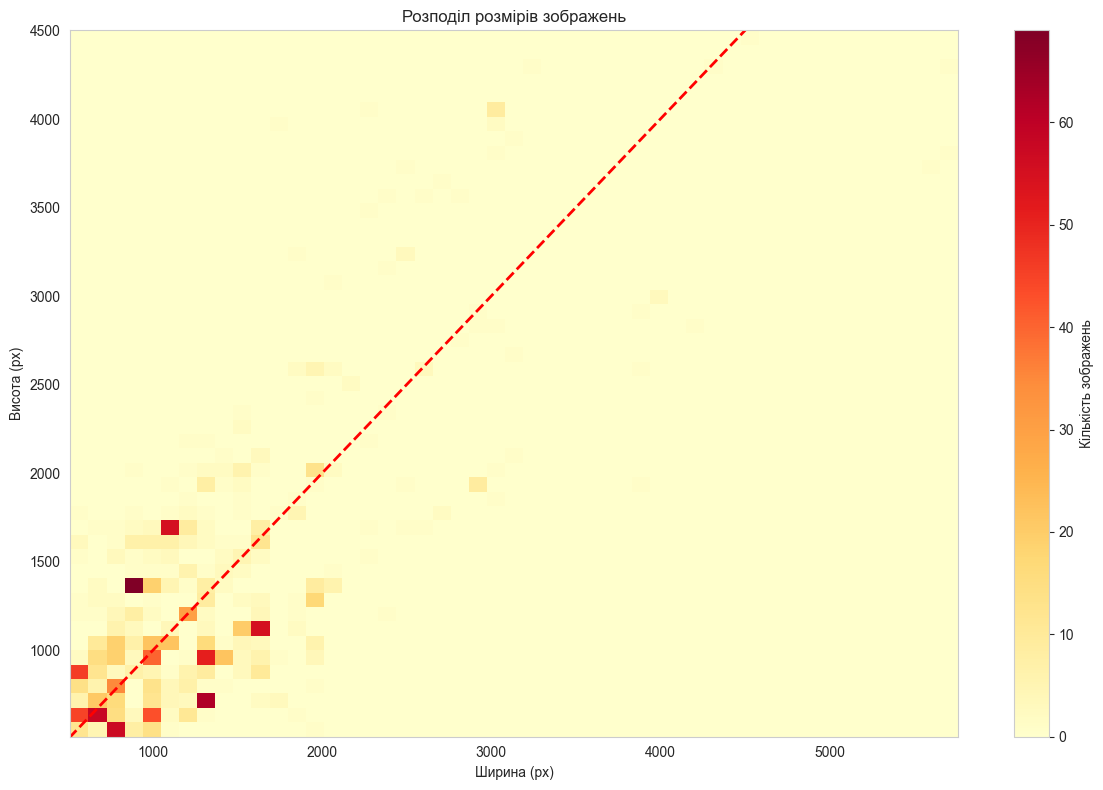

In [14]:
plt.figure(figsize=(12, 8))
width_bins = np.linspace(meta_df['width'].min(), meta_df['width'].max(), 50)
height_bins = np.linspace(meta_df['height'].min(), meta_df['height'].max(), 50)

plt.hist2d(meta_df['width'], meta_df['height'], bins=[width_bins, height_bins], cmap='YlOrRd')
plt.plot([0, max_dim], [0, max_dim], 'r--', label='Square (1:1)', linewidth=2)
plt.colorbar(label='Кількість зображень')
plt.xlabel('Ширина (px)')
plt.ylabel('Висота (px)')
plt.title('Розподіл розмірів зображень')
plt.tight_layout()
plt.show()

## 4. Порівняння розмірів зображень між класами

Щоб краще зрозуміти відмінності між класами, розділимо зображення на категорії за кількістю пікселів:
- **Small (<0.5MP)**
- **Medium (0.5–1MP)**
- **Large (1–2MP)**
- **X-Large (2–5MP)**
- **XX-Large (>5MP)**

Далі побудуємо **stacked bar chart**, щоб побачити, як ці категорії розподілені між класами.

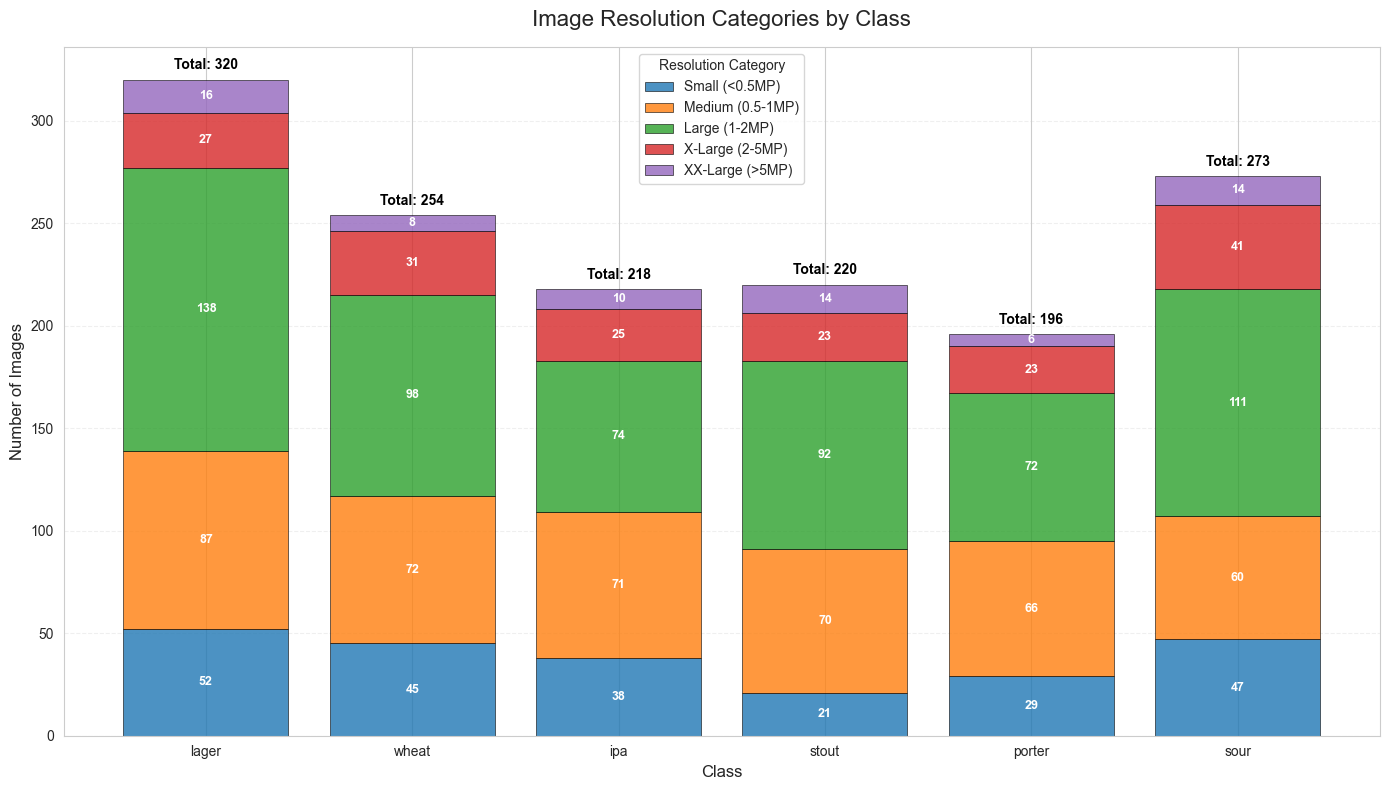

In [19]:
def categorize_resolution(width, height):
    pixels = width * height
    if pixels < 0.5 * 1_000_000:
        return 'Small (<0.5MP)'
    elif pixels < 1 * 1_000_000:
        return 'Medium (0.5-1MP)'
    elif pixels < 2 * 1_000_000:
        return 'Large (1-2MP)'
    elif pixels < 5 * 1_000_000:
        return 'X-Large (2-5MP)'
    else:
        return 'XX-Large (>5MP)'


resolution_by_class = {}
categories = ['Small (<0.5MP)', 'Medium (0.5-1MP)', 'Large (1-2MP)',
              'X-Large (2-5MP)', 'XX-Large (>5MP)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

classes = meta_df['klass'].unique() 

for cls in classes:
    subset = meta_df[meta_df['klass'] == cls]
    resolutions = [categorize_resolution(w, h) for w, h in zip(subset['width'], subset['height'])]
    counts = [resolutions.count(cat) for cat in categories]
    resolution_by_class[cls] = counts


fig, ax = plt.subplots(figsize=(14, 8))
bottom = np.zeros(len(classes))

for i, cat in enumerate(categories):
    values = [resolution_by_class[cls][i] for cls in classes]
    bars = ax.bar(classes, values, bottom=bottom, label=cat, color=colors[i],
                  alpha=0.8, edgecolor='black', linewidth=0.5)

    for j, bar in enumerate(bars):
        if values[j] > 0:
            height = bar.get_height()
            y = bottom[j] + height / 2
            ax.text(bar.get_x() + bar.get_width()/2, y, f"{values[j]}",
                    ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    bottom += values

for i, cls in enumerate(classes):
    total = sum(resolution_by_class[cls])
    ax.text(i, total + 5, f'Total: {total}', ha='center', fontsize=10, fontweight='bold', color='black')

ax.set_title('Image Resolution Categories by Class', fontsize=16, pad=15)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.legend(title='Resolution Category', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 5. Розподіл класів

Подивимось, як розподілені зображення між класами.  
Діаграма показує відсоткове співвідношення кожного класу — це допомагає оцінити баланс даних.  
Якщо якийсь клас суттєво переважає, це може вплинути на навчання моделі.

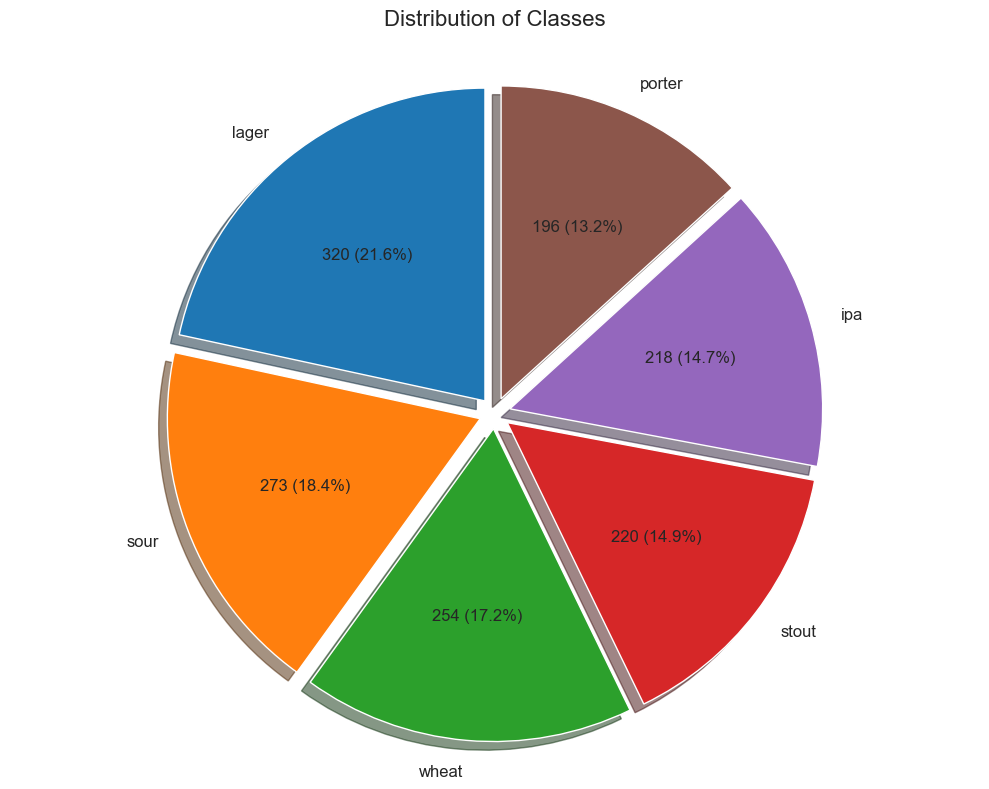

In [25]:
class_counts = meta_df['klass'].value_counts()
total = class_counts.sum()

plt.figure(figsize=(10, 8))

def autopct_format(values):
    def inner(pct):
        count = int(round(pct * total / 100.0))
        return f'{count} ({pct:.1f}%)'
    return inner

plt.pie(class_counts, labels=class_counts.index,
        autopct=autopct_format(class_counts),
        startangle=90, shadow=True, explode=[0.05]*len(class_counts),
        textprops={'fontsize': 12})

plt.title('Distribution of Classes', fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


## 6. Розмірність зображень за класами

Графік розсіювання (scatter plot) показує ширину та висоту кожного зображення.  
Кольори відповідають класам.  
Можна швидко побачити, чи є відмінності у пропорціях або роздільності між класами.

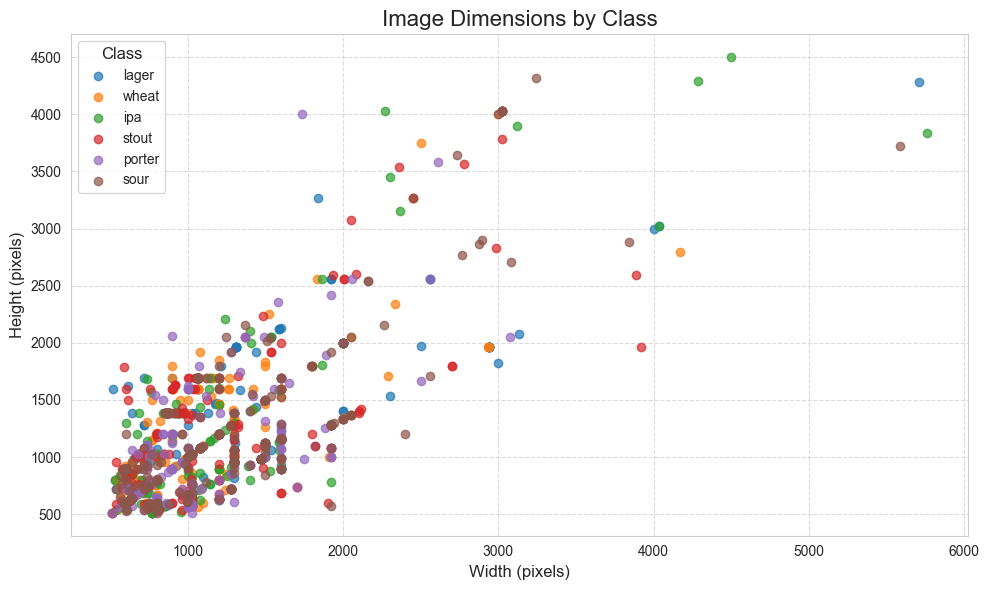

In [22]:
classes = meta_df['klass'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, cls in enumerate(classes):
    subset = meta_df[meta_df['klass'] == cls]
    plt.scatter(subset['width'], subset['height'],
                alpha=0.7, label=cls, color=colors[i % len(colors)])

plt.xlabel('Width (pixels)', fontsize=12)
plt.ylabel('Height (pixels)', fontsize=12)
plt.title('Image Dimensions by Class', fontsize=16)
plt.legend(title='Class', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 7. Співвідношення сторін зображень

Аналізуємо співвідношення ширини до висоти (aspect ratio) для кожного зображення.  
Значення 1.0 означає квадратні зображення, менші — вертикальні, більші — горизонтальні.  
Цей розподіл допомагає зрозуміти, чи є потреба нормалізувати пропорції під час попередньої обробки.


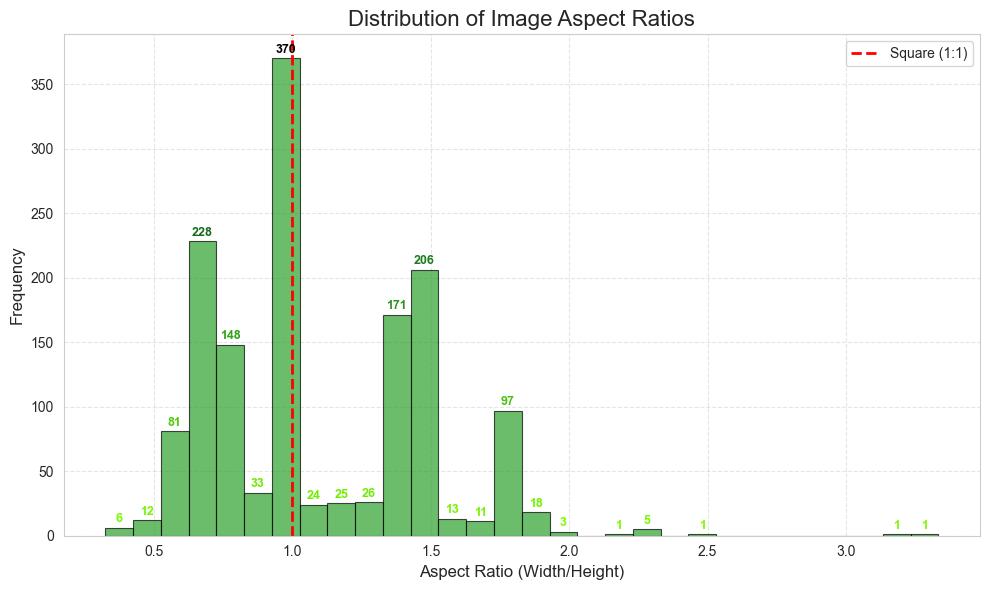

In [34]:
from matplotlib.colors import LinearSegmentedColormap

aspect_ratios = meta_df['width'] / meta_df['height']

counts, bins, patches = plt.hist(aspect_ratios, bins=30, alpha=0.7, color='#2ca02c',
                                 edgecolor='black', linewidth=0.8)

plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Square (1:1)')

colors = ['#7CFC00', '#228B22', '#000000']  # lime → forest → black
custom_cmap = LinearSegmentedColormap.from_list('GreenToBlack', colors)

norm = plt.Normalize(vmin=min(counts), vmax=max(counts))

for i in range(len(counts)):
    if counts[i] > 0:
        x_center = (bins[i] + bins[i+1]) / 2
        y = counts[i]
        color = custom_cmap(norm(y))  
        plt.text(x_center, y + 2, f'{int(y)}',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold',
                 color=color)

plt.title('Distribution of Image Aspect Ratios', fontsize=16)
plt.xlabel('Aspect Ratio (Width/Height)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Розподіл розмірів зображень за класами

Boxplot показує статистичний розподіл ширини та висоти для кожного класу.  
Можна побачити медіану, діапазон і можливі викиди (outliers).  
Це допомагає оцінити стабільність даних і знайти потенційні аномалії у вибірці.


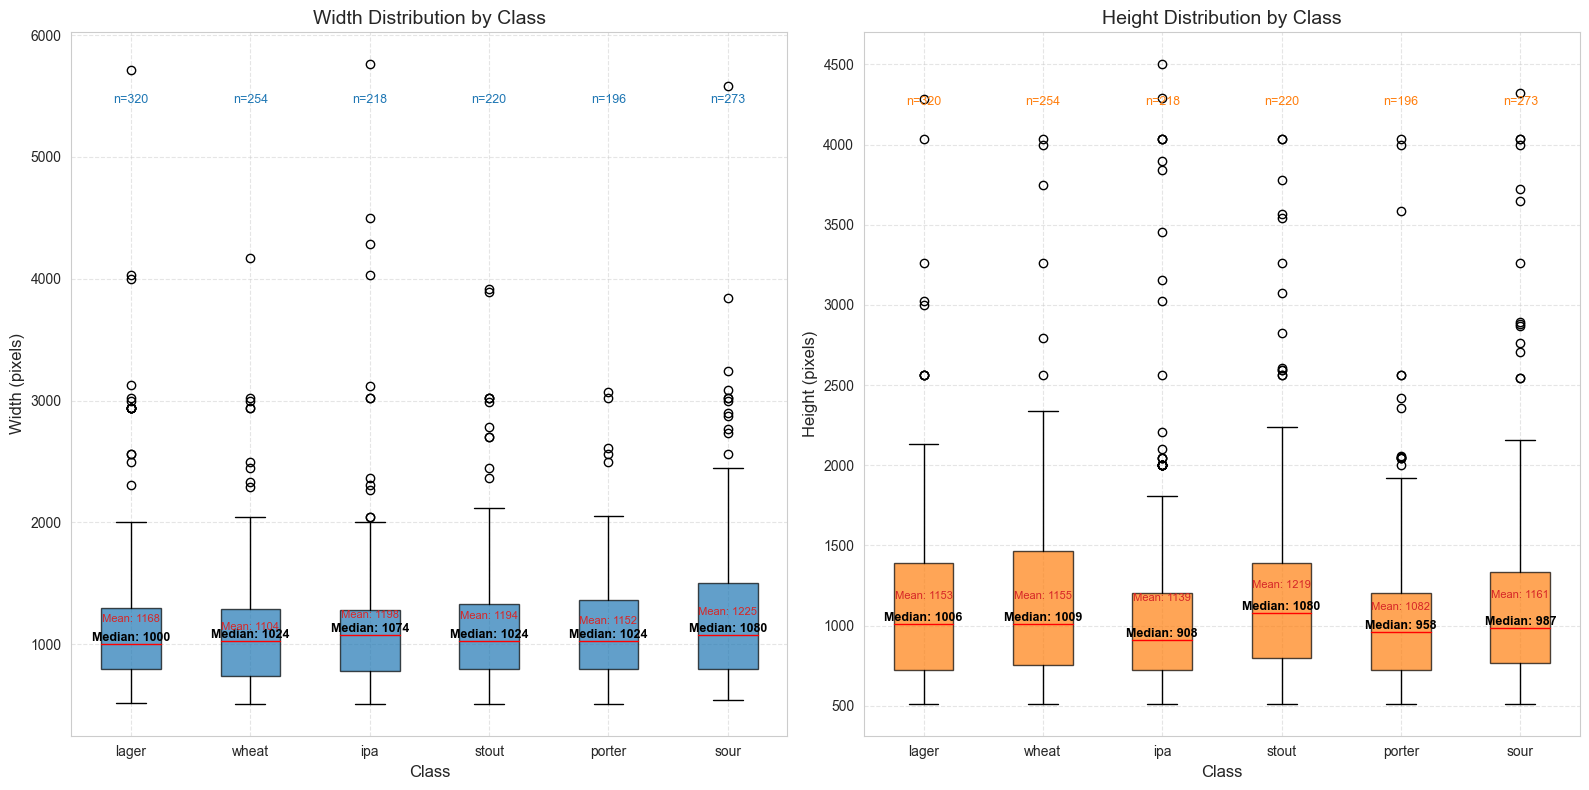

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

classes = meta_df['klass'].unique()

width_by_class = [meta_df[meta_df['klass'] == cls]['width'] for cls in classes]
box1 = ax1.boxplot(width_by_class, labels=classes, patch_artist=True,
                   boxprops=dict(facecolor='#1f77b4', alpha=0.7),
                   medianprops=dict(color='red'))

ax1.set_title('Width Distribution by Class', fontsize=14)
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Width (pixels)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

for i, cls in enumerate(classes):
    median = np.median(width_by_class[i])
    mean = np.mean(width_by_class[i])
    count = len(width_by_class[i])

    ax1.text(i + 1, median, f'Median: {median:.0f}', ha='center',
             va='bottom', fontsize=9, color='black', fontweight='bold')

    ax1.text(i + 1, mean, f'Mean: {mean:.0f}', ha='center',
             va='bottom', fontsize=8, color='#d62728')

    ax1.text(i + 1, ax1.get_ylim()[1] * 0.9, f'n={count}', ha='center',
             va='bottom', fontsize=9, color='#1f77b4')

height_by_class = [meta_df[meta_df['klass'] == cls]['height'] for cls in classes]
box2 = ax2.boxplot(height_by_class, labels=classes, patch_artist=True,
                   boxprops=dict(facecolor='#ff7f0e', alpha=0.7),
                   medianprops=dict(color='red'))

ax2.set_title('Height Distribution by Class', fontsize=14)
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Height (pixels)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

for i, cls in enumerate(classes):
    median = np.median(height_by_class[i])
    mean = np.mean(height_by_class[i])
    count = len(height_by_class[i])

    ax2.text(i + 1, median, f'Median: {median:.0f}', ha='center',
             va='bottom', fontsize=9, color='black', fontweight='bold')

    ax2.text(i + 1, mean, f'Mean: {mean:.0f}', ha='center',
             va='bottom', fontsize=8, color='#d62728')

    ax2.text(i + 1, ax2.get_ylim()[1] * 0.9, f'n={count}', ha='center',
             va='bottom', fontsize=9, color='#ff7f0e')

plt.tight_layout()
plt.show()

## 9. Приклади зображень

Витягнемо приклади зображень з наших класів.

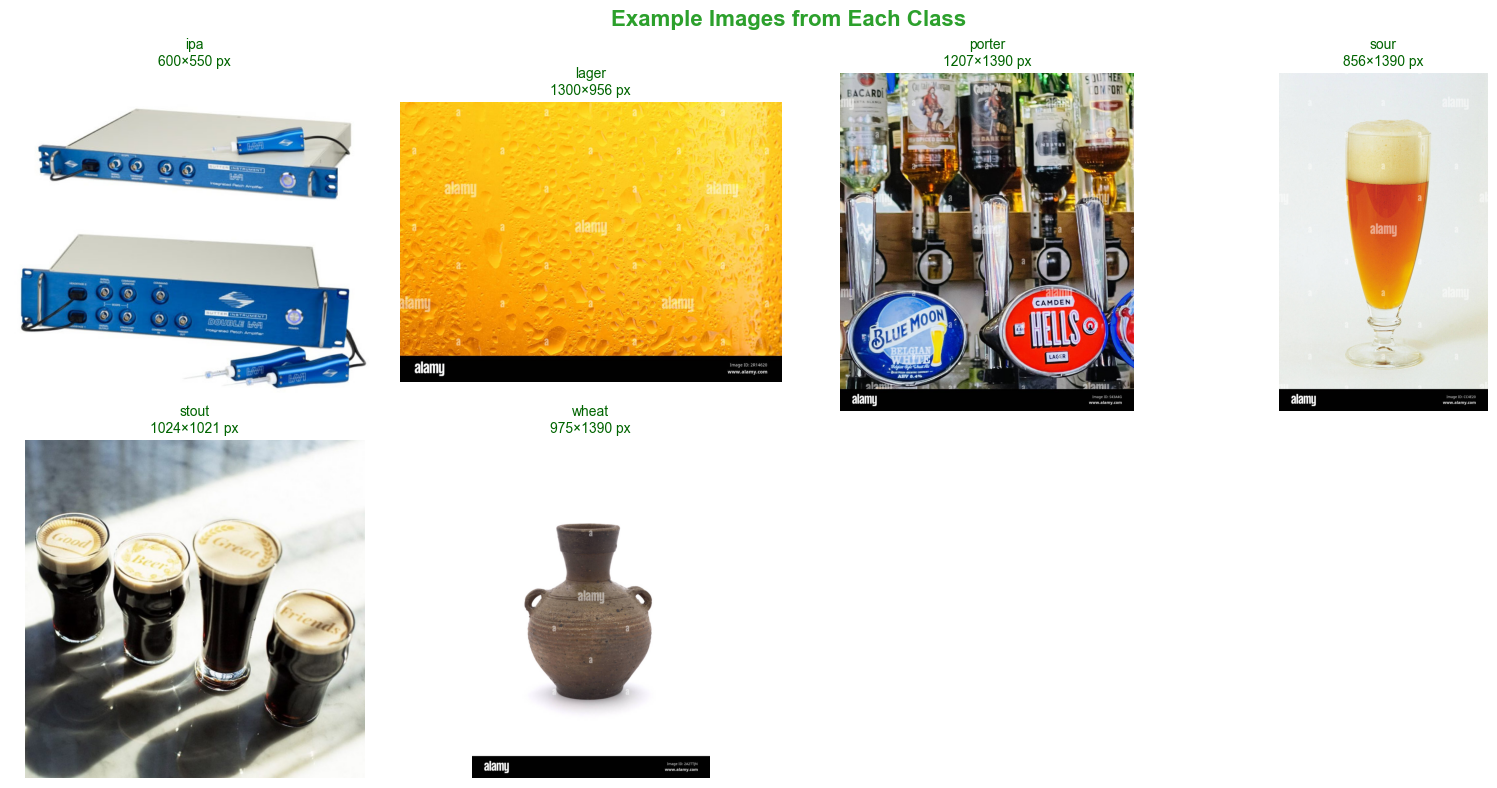

In [44]:
samples = meta_df.groupby('klass', group_keys=False).apply(lambda x: x.sample(1, random_state=42))

n_classes = len(samples)
cols = min(n_classes, 4)
rows = int(np.ceil(n_classes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, samples.iterrows()):
    try:
        img = Image.open(row['orig_path'])
        ax.imshow(img)
        ax.set_title(f"{row['klass']}\n{img.size[0]}×{img.size[1]} px",
                     fontsize=10, color='darkgreen', pad=6)
        ax.axis('off')
    except Exception:
        ax.set_visible(False)

for ax in axes[len(samples):]:
    ax.set_visible(False)

plt.suptitle('Example Images from Each Class', fontsize=16, fontweight='bold', color='#2ca02c')
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## 10. Висновок щодо якості даних

### Загальні спостереження
- Датасет складається з кількох класів пива (`lager`, `ipa`, `wheat`, `sour`, тощо), однак баланс між класами помірно нерівномірний — це видно з кругової діаграми.  
  Варто буде збалансувати вибірку перед тренуванням моделі (через oversampling або data augmentation).
- Метадані включають розміри зображень (`width`, `height`), джерело (`source`, `source_url`) та час додавання (`added_at`), що дає можливість відслідковувати походження даних.

### Аналіз розмірів і пропорцій
- **Теплова карта** ширини й висоти показала, що більшість зображень мають помірну роздільність (від ~500×500 до ~1500×1500 px), проте зустрічаються і дуже великі значення (>3000 px).  
  Це свідчить про потребу стандартизації розмірів перед навчанням.
- Аналіз категорій роздільності показав, що переважають класи `Medium (0.5–1MP)` і `Large (1–2MP)`.  
  Тобто більшість зображень мають достатню якість, але є й низькороздільні зразки, які варто відфільтрувати.
- **Boxplots** підтвердили, що розподіл ширини й висоти подібний між класами, але з невеликими викидами — можливо, деякі зображення некоректні або обрізані.

### Співвідношення сторін
- Розподіл aspect ratio концентрується навколо 1.0 (тобто більшість зображень квадратні або близькі до квадрату).  
  Є кілька екстремальних значень (високі чи витягнуті фото) — бажано привести всі зображення до єдиного формату (наприклад, `224×224` або `256×256` перед подачею в модель).
- Найчастіше зустрічаються співвідношення 0.7–1.3, що спрощує масштабування без втрати суттєвих деталей.

### Візуалізація прикладів
- Приклади зображень показали, що частина фото дійсно відповідає класам пива (пляшки, келихи, пінка), але інші містять сторонні об’єкти — чайники, вази, посуд, іноді навіть не напої.  
  Це вказує на **низьку точність збору** даних із пошукових систем.
- Варто провести автоматичну фільтрацію або ручну модерацію. Можна використати:
  - **CLIP / ViT embeddings** для порівняння семантичної схожості із запитом “beer”;
  - **перевірку назв файлів і URL** на наявність ключових слів;
  - **кластеризацію ознак** (наприклад, через PCA або t-SNE), щоб виділити “аномальні” зображення.

### Кольорові та візуальні особливості
- Кольори відрізняються між класами: зображення пшеничного пива (`wheat`) мають світлі жовті відтінки, тоді як темні сорти (`stout`, `porter`) — насичено-коричневі.  
  Це можна використати як ознаку під час навчання (через середні RGB або гістограму кольорів).
- Частина фото має білий або прозорий фон — це потенційно корисно для сегментації, але може зашкодити класифікації, якщо фонів багато і вони різні.

### Проблеми якості даних
- У `orig_path` трапляються шляхи, які не ведуть до зображень або містять пошкоджені файли — це потрібно перевірити.  
- Є різні джерела (`source`), що можуть мати різну якість і формат, тому бажано уніфікувати формат (наприклад, `.jpg`, `.png`).
- Частина зображень дублюється або дуже схожа (що типово для результатів crawler'ів).

---

### Рекомендації для препроцесингу
1. **Очищення даних**
   - Видалити пошкоджені або нерелевантні зображення (автоматично або вручну).  
   - Використати модель CLIP для відбору зображень, де семантика відповідає beer-related контенту.
2. **Фільтрація розмірів**
   - Прибрати зображення з надто малою роздільністю (<400×400 px).  
   - Змінити розміри всіх зображень до єдиного формату.
3. **Збалансування класів**
   - Виконати oversampling для малочисельних класів або data augmentation (flip, rotation, color jitter).
4. **Колірна нормалізація**
   - Привести кольорові канали до спільного діапазону (наприклад, `RGB / 255` або `ImageNet mean/std`).
5. **Перевірка дублікатів**
   - Використати image hashing (`imagehash.average_hash`) для виявлення дубльованих фото.
6. **Підготовка до моделі**
   - Зберігати шляхи у форматі `Path` або `PosixPath`, щоб легко завантажувати батчі.  
   - Створити train/val/test split із рівномірним розподілом класів.

---

### Загальний висновок
Датасет *Neural Beer* має потенціал для побудови моделі класифікації типів пива,  
але на даному етапі потребує значного очищення:  
у ньому присутні нерелевантні зображення, варіації форматів і розмірів,  
а також легкий дисбаланс класів.  
Після ретельного препроцесингу та нормалізації даних цей набір може стати якісною основою для комп’ютерного зору або мультимодальної системи розпізнавання пива.

